In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [56]:
df = pd.read_csv("single_genre_artists.csv")

In [4]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [4]:
print("R,C:",df.shape)
print("dup:",df.duplicated().sum())
print("null:", df.isnull().sum())

R,C: (95837, 23)
dup: 0
null: id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity_songs,95837.0,26.066394,16.254133,0.00000,13.0000,26.000000,37.0000,9.800000e+01
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4.800118e+06
explicit,95837.0,0.029644,0.169604,0.00000,0.0000,0.000000,0.0000,1.000000e+00
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,9.910000e-01
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000000e+00
key,95837.0,5.196782,3.534923,0.00000,2.0000,5.000000,8.0000,1.100000e+01
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376000e+00
mode,95837.0,0.648069,0.477575,0.00000,0.0000,1.000000,1.0000,1.000000e+00
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,9.680000e-01
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,9.960000e-01


#### features

In [70]:
df.drop([
    'id_songs',
    'name_song',
    'id_artists',
    'release_date',
    'genres',
    'name_artists'
], axis=1, inplace=True)

In [5]:
recommended_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

In [6]:
X = df[recommended_features]

In [18]:
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973


In [63]:
X.corr()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
danceability,1.000000,0.204810,0.161041,0.229137,-0.186992,-0.189374,-0.030714,0.504279,-0.083170,-0.134197
energy,0.204810,1.000000,0.734616,-0.096334,-0.663945,-0.130171,0.082891,0.361499,0.210389,0.096509
loudness,0.161041,0.734616,1.000000,-0.254914,-0.457045,-0.229224,-0.045746,0.235866,0.190798,0.093598
speechiness,0.229137,-0.096334,-0.254914,1.000000,0.137110,-0.138109,0.407153,0.026236,-0.204813,-0.319019
acousticness,-0.186992,-0.663945,-0.457045,0.137110,1.000000,0.145857,0.048106,-0.173949,-0.185997,-0.131308
instrumentalness,-0.189374,-0.130171,-0.229224,-0.138109,0.145857,1.000000,-0.069307,-0.137493,-0.021467,0.069550
liveness,-0.030714,0.082891,-0.045746,0.407153,0.048106,-0.069307,1.000000,0.016515,-0.091685,-0.124938
valence,0.504279,0.361499,0.235866,0.026236,-0.173949,-0.137493,0.016515,1.000000,0.121456,-0.137322
tempo,-0.083170,0.210389,0.190798,-0.204813,-0.185997,-0.021467,-0.091685,0.121456,1.000000,0.073963
duration_ms,-0.134197,0.096509,0.093598,-0.319019,-0.131308,0.069550,-0.124938,-0.137322,0.073963,1.000000


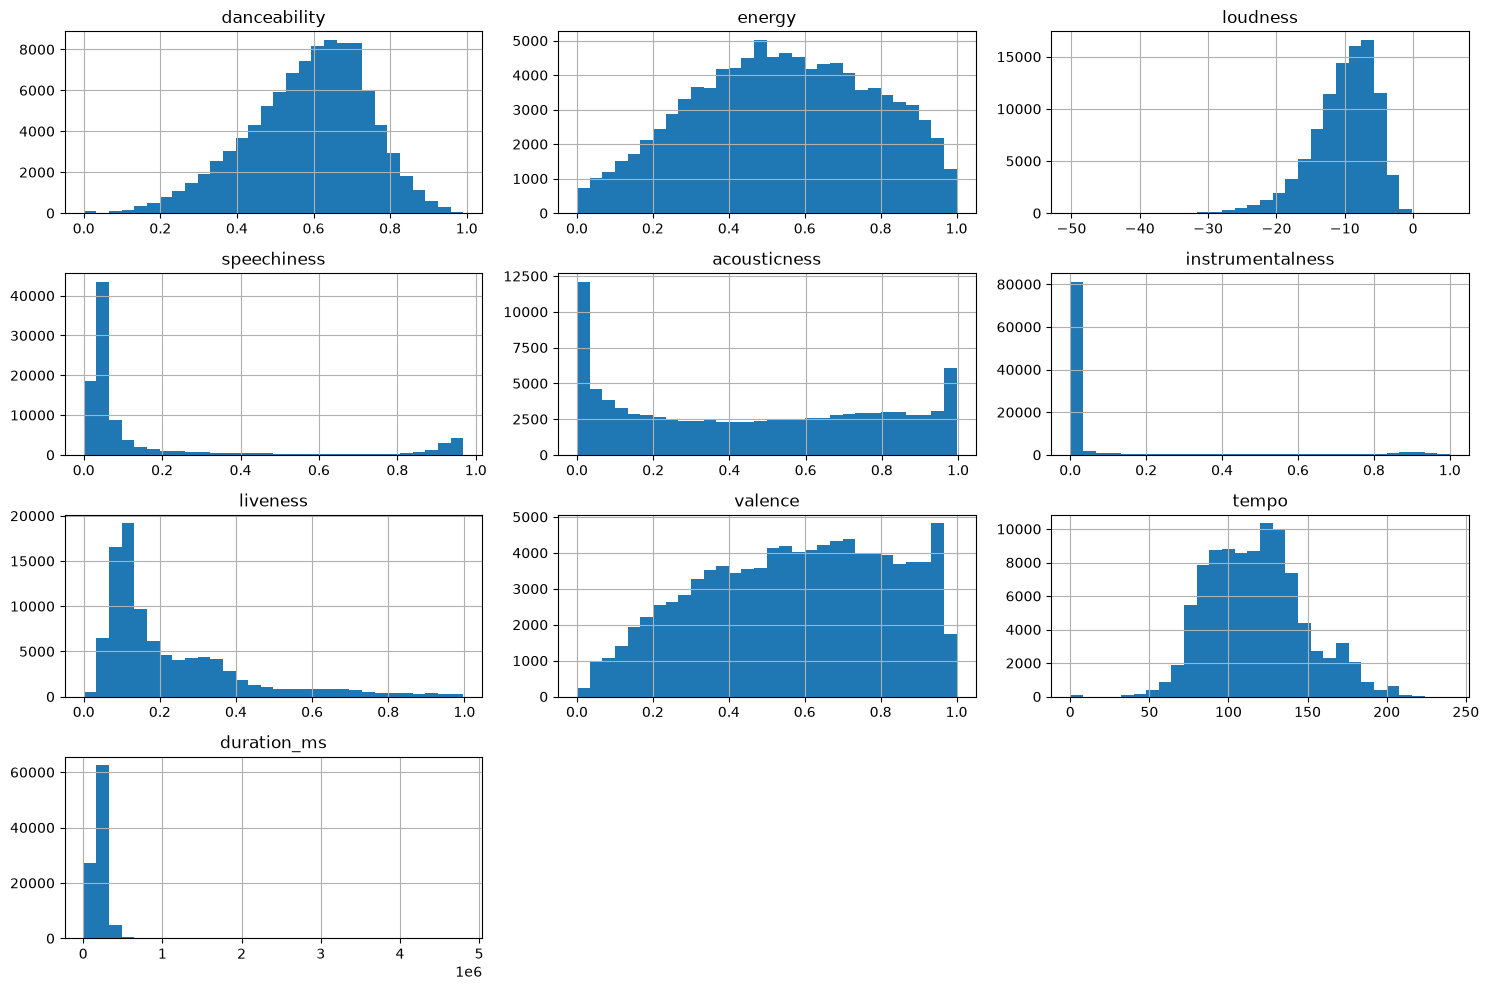

In [64]:
X.hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

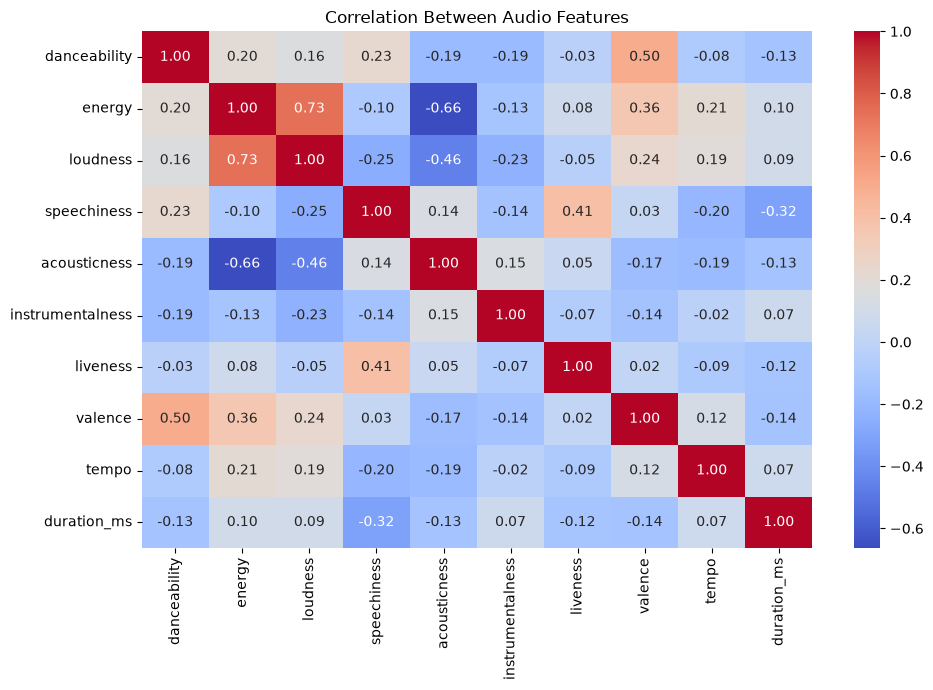

In [65]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

### Standardization

In [7]:
scaler = StandardScaler()

In [8]:
X_scaled = scaler.fit_transform(X)

In [9]:
## Convert it back to DataFrame

df_scaled=pd.DataFrame(X_scaled,columns=recommended_features,index=X.index)

In [24]:
df_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-0.401735
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,0.124906
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,-0.003949
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,-0.397437
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,-0.346143


#### K-Means + Elbow Method + Silhouette Score

In [10]:
from sklearn.cluster import KMeans

In [ ]:
x_sample=X_scaled[:10000]
print(x_sample.shape)
print(X_scaled.shape)

(10000, 10)
(95837, 10)


In [14]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(x_sample)
    
    inertia.append(kmeans.inertia_)

In [15]:
inertia

[84084.55626590706,
 71868.01805893448,
 62045.27172780161,
 56678.519918066275,
 52246.993847888676,
 48445.048768041335,
 45836.647599769465,
 43523.87533092957,
 41600.73389642952]

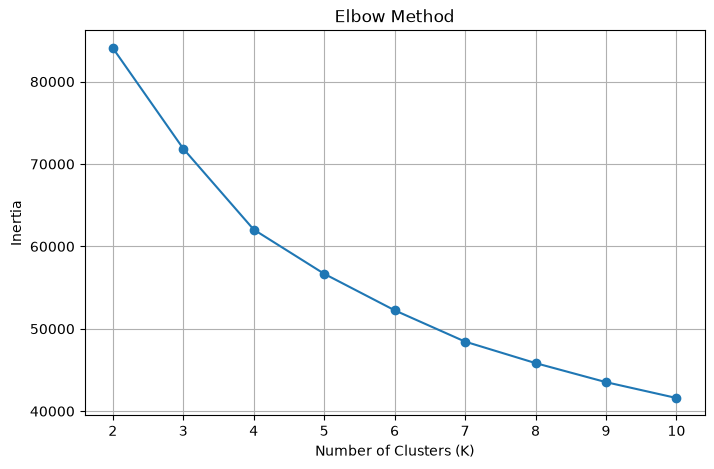

In [16]:
### Plot the Elbow

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)
plt.show()

In [17]:
## Silhouette Score
from sklearn.metrics import silhouette_score

In [10]:
X_scaled.shape

(95837, 10)

In [11]:
x_sample=X_scaled[:10000]
print(x_sample.shape)
print(X_scaled.shape)

(10000, 10)
(95837, 10)


In [18]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(x_sample)
    
    score = silhouette_score(x_sample, labels)
    silhouette_scores.append(score)


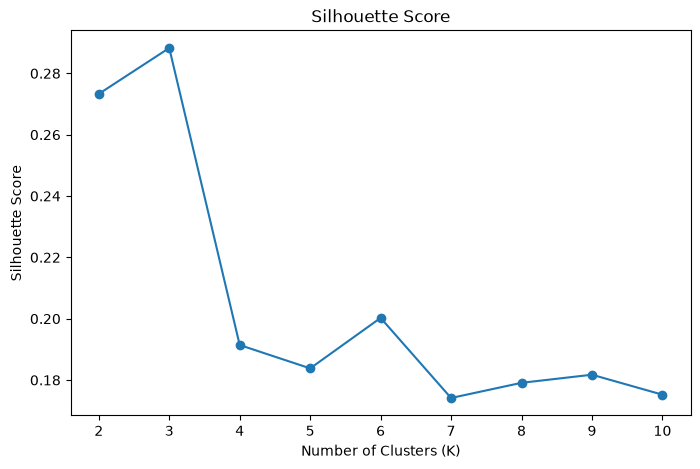

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [19]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.2733
K = 3: Silhouette Score = 0.2883
K = 4: Silhouette Score = 0.1914
K = 5: Silhouette Score = 0.1838
K = 6: Silhouette Score = 0.2003
K = 7: Silhouette Score = 0.1741
K = 8: Silhouette Score = 0.1791
K = 9: Silhouette Score = 0.1817
K = 10: Silhouette Score = 0.1752


#### I tested different values of K using the Silhouette Score. K = 3 achieved the highest Silhouette Score, so I selected 3 as the optimal number of clusters.”

In [14]:
best_idx = np.argmax(silhouette_scores)

best_k = list(range(2,11))[best_idx]

best_score = silhouette_scores[best_idx]

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 3
Best Silhouette Score: 0.2883


### Final K-Means + Evaluation

In [20]:
k =3

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

In [21]:
# train clusters
kmeans_labels = kmeans_final.fit_predict(X_scaled)

In [61]:
df['kmeans_cluster'] = kmeans_labels

In [62]:
df['kmeans_cluster'].value_counts()

kmeans_cluster
2    52517
1    30807
0    12513
Name: count, dtype: int64

In [24]:
## K-Means Evaluation

silhouette = silhouette_score(
    X_scaled,
    kmeans_labels,
    sample_size=1000,
    random_state=42
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2465


#### Davies-Bouldin Indexm

In [25]:
from sklearn.metrics import davies_bouldin_score

In [26]:
davies = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

inertia_final = kmeans_final.inertia_

print("\n========== K-MEANS RESULTS ==========")


========== K-MEANS RESULTS ==========


In [27]:
inertia_final

658335.0812701196

In [28]:
print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(davies, 4)
)

print(
    "Inertia:",
    round(inertia_final, 2)
)


Silhouette Score: 0.2465
Davies-Bouldin Index: 1.5702
Inertia: 658335.08


In [29]:
# CLUSTER SIZE
cluster_count = (
    df["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster Distribution:")

display(cluster_count)


Cluster Distribution:


kmeans_cluster
0    12513
1    30807
2    52517
Name: count, dtype: int64

In [30]:
cluster_percentage = (
    df["kmeans_cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
print(cluster_percentage)

kmeans_cluster
0    13.056544
1    32.145205
2    54.798251
Name: proportion, dtype: float64


#####  CLUSTER PROFILE

In [31]:
cluster_profile = (
    df.groupby("kmeans_cluster")[recommended_features]
    .mean()
    .round(3)
)
print(cluster_profile)

                danceability  energy  loudness  speechiness  acousticness  \
kmeans_cluster                                                              
0                      0.664   0.467   -13.364        0.830         0.586   
1                      0.486   0.311   -13.205        0.060         0.749   
2                      0.627   0.694    -7.606        0.075         0.258   

                instrumentalness  liveness  valence    tempo  duration_ms  
kmeans_cluster                                                             
0                          0.001     0.436    0.584  100.389    97520.590  
1                          0.169     0.182    0.413  111.940   223457.064  
2                          0.051     0.200    0.666  124.911   226592.053  


## Cluster Interpretation

##### Cluster 0 — Speech-oriented / Short Tracks
The very high speechiness makes this cluster different from the others.

##### Cluster 1 — Acoustic / Calm Tracks
These songs have relatively high acoustic characteristics and lower energy.

##### Cluster 2 — Energetic / Dance-oriented Tracks

These songs have higher energy and tempo.



In [32]:
from sklearn.decomposition import PCA

In [33]:
profile_scaled = (
    pd.DataFrame(
        X_scaled,
        columns=recommended_features
    )
    .assign(
        kmeans_cluster=kmeans_labels
    )
    .groupby("kmeans_cluster")
    .mean()
    .round(2)
)

display(profile_scaled)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
kmeans_cluster,,,,,,,,,,
0,0.50,-0.32,-0.68,2.40,0.38,-0.35,1.13,0.04,-0.57,-0.94
1,-0.65,-0.97,-0.64,-0.39,0.88,0.37,-0.23,-0.65,-0.19,0.13
2,0.26,0.65,0.54,-0.34,-0.61,-0.14,-0.13,0.37,0.24,0.15


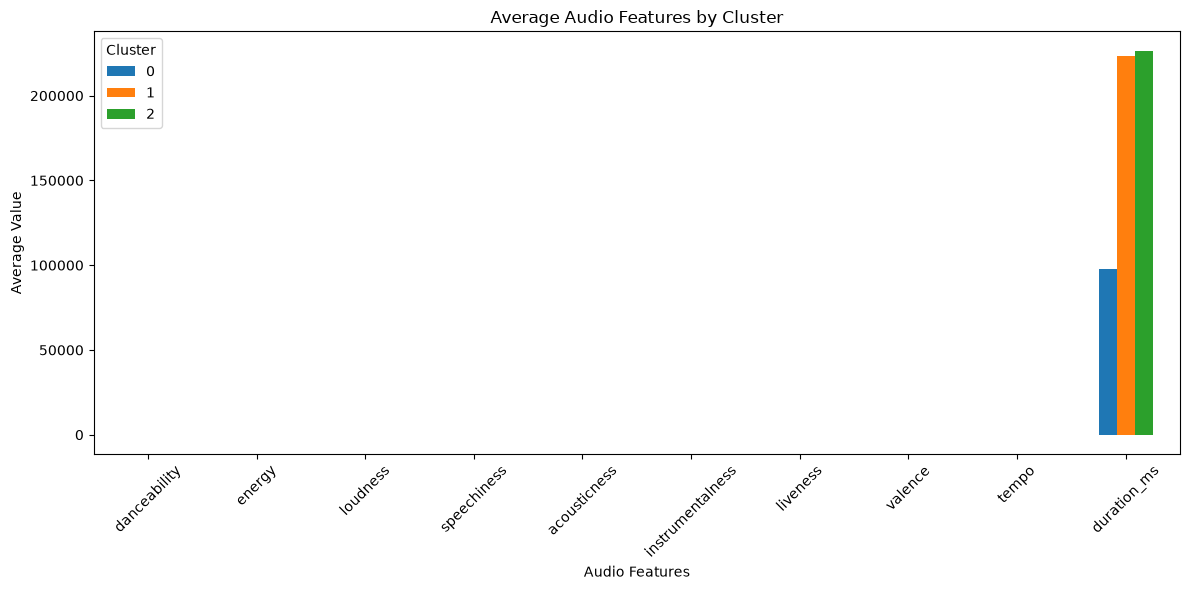

In [34]:
## Cluster Visualization

cluster_profile.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Average Audio Features by Cluster"
)

plt.xlabel("Audio Features")

plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

#### PCA Visualization

In [35]:
pca = PCA(
    n_components=2,
    random_state=42
)

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PCA1", "PCA2"]
)

pca_df["cluster"] = kmeans_labels

In [36]:
pca_df["cluster"].value_counts()

cluster
2    52517
1    30807
0    12513
Name: count, dtype: int64

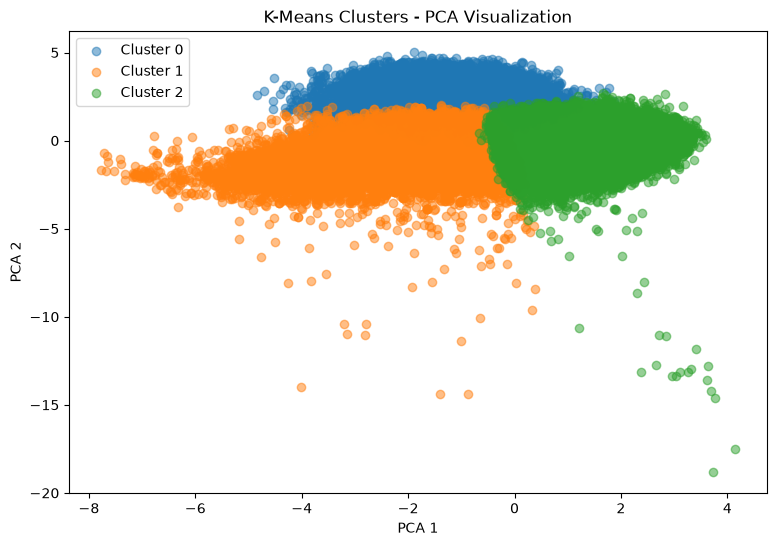

In [110]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["cluster"].unique()):
    data = pca_df[pca_df["cluster"] == cluster]

    plt.scatter(
        data["PCA1"],
        data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters - PCA Visualization")

plt.legend()
plt.show()

In [59]:
### PCA Explained Variance


print(
    "PCA 1:",
    round(
        pca.explained_variance_ratio_[0],
        4
    )
)

print(
    "PCA 2:",
    round(
        pca.explained_variance_ratio_[1],
        4
    )
)

print(
    "Total:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

PCA 1: 0.2708
PCA 2: 0.1882
Total: 0.459


### DBSCAN

In [39]:
from sklearn.cluster import DBSCAN

In [40]:
X_sample = X_scaled[:10000]

dbscan = DBSCAN(
    eps=1.8,
    min_samples=12
)

dbscan_labels = dbscan.fit_predict(X_sample)

In [41]:
unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

print(
    dict(zip(unique_labels, counts))
)

{np.int64(-1): np.int64(327), np.int64(0): np.int64(9621), np.int64(1): np.int64(52)}


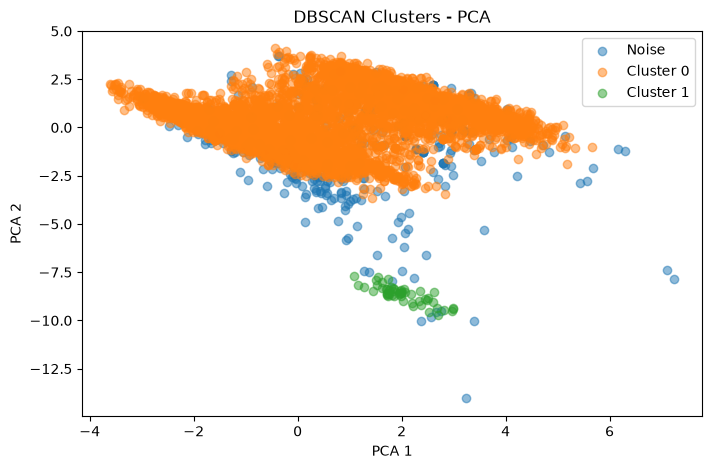

In [103]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(8, 5))

for label in np.unique(dbscan_labels):

    mask = dbscan_labels == label

    if label == -1:
        name = "Noise"
    else:
        name = f"Cluster {label}"

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=name,
        alpha=0.5
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN Clusters - PCA")
plt.legend()

plt.show()


### Hierarchical Clustering

In [45]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage,dendrogram

In [44]:
np.random.seed(42)

sample_size = 1000

sample_indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[
    sample_indices
]

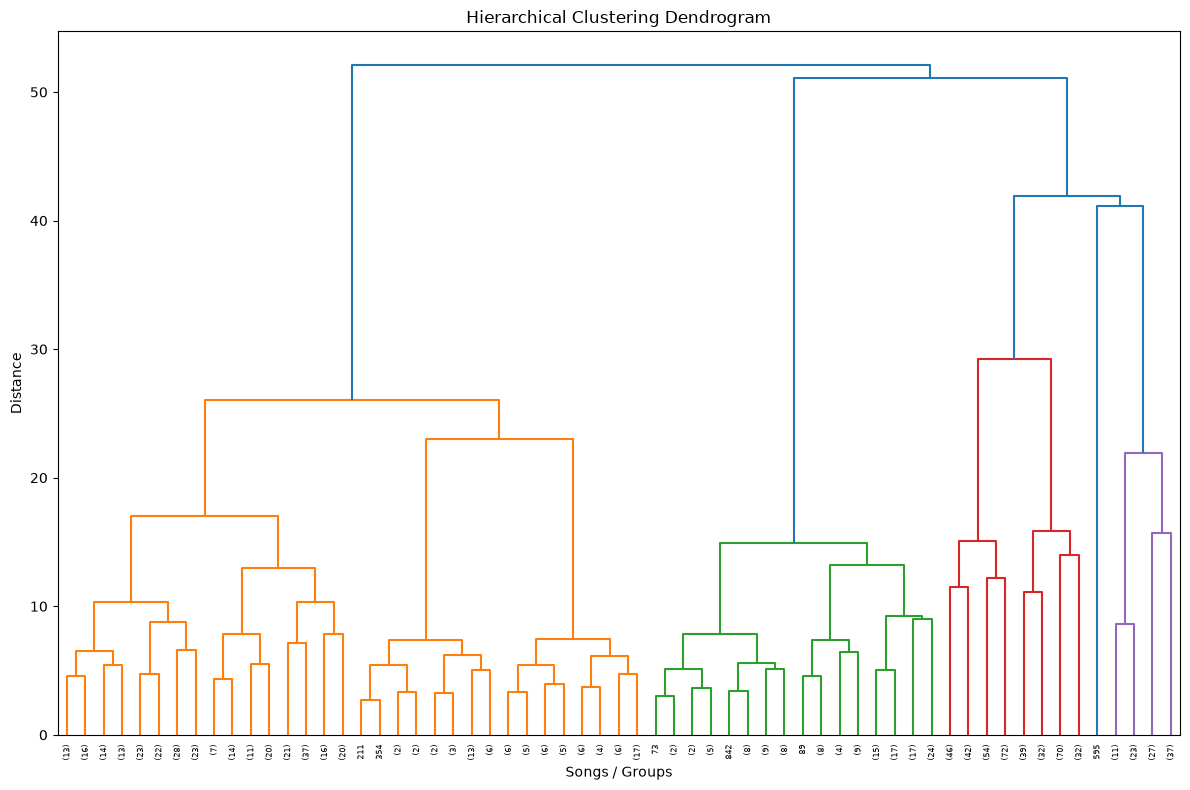

In [49]:
# Dendrogram
linked = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(12, 8))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Songs / Groups")

plt.ylabel("Distance")

plt.tight_layout()

plt.show()


In [50]:
# Algorithm Comparison
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hier_labels = hierarchical.fit_predict(
    X_sample
)

### Evaluation

In [58]:
hier_silhouette = silhouette_score(
    X_sample,
    hier_labels
)

hier_davies = davies_bouldin_score(
    X_sample,
    hier_labels
)

print(
    "Hierarchical Silhouette:",
    round(hier_silhouette, 4)
)

print(
    "Hierarchical Davies-Bouldin:",
    round(hier_davies, 4)
)

Hierarchical Silhouette: 0.1806
Hierarchical Davies-Bouldin: 1.7661


#### Genre Inference

In [71]:
original_df = pd.read_csv(
    "single_genre_artists.csv"
)

original_df["kmeans_cluster"] = (
    kmeans_labels
)

In [93]:
original_df.head(1)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,kmeans_cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,1


In [94]:
original_df["genres"] = original_df["kmeans_cluster"].map({
    0: "Hörspiel / Spoken & Story Content",
    1: "Calm / Classic Music",
    2: "Energetic / Pop-Oriented Music"
})

In [95]:
original_df.head(1)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,kmeans_cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,Calm / Classic Music,Mistinguett,22,1


In [96]:
genre_cluster = pd.crosstab(
    original_df["genres"],
    original_df["kmeans_cluster"]
)

display(genre_cluster)

kmeans_cluster,0,1,2
genres,,,
Calm / Classic Music,0,30807,0
Energetic / Pop-Oriented Music,0,0,52517
Hörspiel / Spoken & Story Content,12513,0,0


In [98]:
# Final Export
original_df.to_csv(
    "amazon_music_final_clusters.csv",
    index=False
)

In [99]:

original_df.head(1)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,kmeans_cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,Calm / Classic Music,Mistinguett,22,1


In [100]:
cluster_profile.to_csv(
    "amazon_music_cluster_profile.csv"
)

In [101]:
display(cluster_profile)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
kmeans_cluster,,,,,,,,,,
0,0.664,0.467,-13.364,0.830,0.586,0.001,0.436,0.584,100.389,97520.590
1,0.486,0.311,-13.205,0.060,0.749,0.169,0.182,0.413,111.940,223457.064
2,0.627,0.694,-7.606,0.075,0.258,0.051,0.200,0.666,124.911,226592.053


#  Final Conclusion
The Amazon Music clustering project used unsupervised machine
learning to group 95,837 songs based on their audio characteristics.

After EDA and preprocessing, 10 audio features were selected and
standardized using StandardScaler.

K-Means was selected as the primary clustering algorithm. The Elbow
Method and Silhouette Score indicated K = 3 as the appropriate
cluster count.

The final K-Means model produced three interpretable song groups.

*Cluster 0* represents speech-oriented and shorter tracks, characterized by very high speechiness and relatively high danceability.

 Cluster 1 represents acoustic and calmer tracks, with high acousticness and low energy. 
 
 Cluster 2 represents energetic and upbeat tracks, characterized by high energy, tempo, danceability, loudness, and

PCA was used to visualize the clusters, while DBSCAN and Hierarchical
Clustering were tested as alternative approaches.

The resulting clusters can support applications such as music
segmentation, playlist creation and recommendation systems.

In [102]:
print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original features: 10
PCA components: 2
Explained variance ratio: [0.25549834 0.18472199]
Total explained variance: 0.4402203225433094
